# **Finding How The Data Is Distributed**

In this lab, you will work with a cleaned dataset to perform Exploratory Data Analysis (EDA). You will examine the structure of the data, visualize key variables, and analyze trends related to developer experience, tools, job satisfaction, and other important aspects.

## Objectives

In this lab you will perform the following:

- Understand the structure of the dataset.

- Perform summary statistics and data visualization.

- Identify trends in developer experience, tools, job satisfaction, and other key variables.

### Install the required libraries

In [1]:
#!pip install pandas
#!pip install matplotlib
#!pip install seaborn

### Step 1: Import Libraries and Load Data

- Import the `pandas`, `matplotlib.pyplot`, and `seaborn` libraries.

- You will begin with loading the dataset. You can use the pyfetch method if working on JupyterLite. Otherwise, you can use pandas' read_csv() function directly on their local machines or cloud environments.

In [2]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Stack Overflow survey dataset
data_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv'
df = pd.read_csv(data_url)

# Display the first few rows of the dataset
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Step 2: Examine the Structure of the Data

- Display the column names, data types, and summary information to understand the data structure.

- Objective: Gain insights into the dataset's shape and available variables.

In [3]:
# Display column names
print(df.columns)

Index(['ResponseId', 'MainBranch', 'Age', 'Employment', 'RemoteWork', 'Check',
       'CodingActivities', 'EdLevel', 'LearnCode', 'LearnCodeOnline',
       ...
       'JobSatPoints_6', 'JobSatPoints_7', 'JobSatPoints_8', 'JobSatPoints_9',
       'JobSatPoints_10', 'JobSatPoints_11', 'SurveyLength', 'SurveyEase',
       'ConvertedCompYearly', 'JobSat'],
      dtype='object', length=114)


In [4]:
# Display data types of all columns
print(df.dtypes)

ResponseId               int64
MainBranch              object
Age                     object
Employment              object
RemoteWork              object
                        ...   
JobSatPoints_11        float64
SurveyLength            object
SurveyEase              object
ConvertedCompYearly    float64
JobSat                 float64
Length: 114, dtype: object


In [5]:
# Display summary information about the dataset
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65437 entries, 0 to 65436
Columns: 114 entries, ResponseId to JobSat
dtypes: float64(13), int64(1), object(100)
memory usage: 56.9+ MB
None


In [6]:
# Display dataset shape (rows and columns)
print("Dataset Shape:", df.shape)

Dataset Shape: (65437, 114)


### Step 3: Handle Missing Data

- Identify missing values in the dataset.

- Impute or remove missing values as necessary to ensure data completeness.

In [10]:
# Check missing values in all columns
missing_values = df.isnull().sum()

missing_values

ResponseId                 0
MainBranch                 0
Age                        0
Employment                 0
RemoteWork             10631
                       ...  
JobSatPoints_11        35992
SurveyLength            9255
SurveyEase              9199
ConvertedCompYearly    42002
JobSat                 36311
Length: 114, dtype: int64

In [11]:
# Display columns with missing values only
print(missing_values[missing_values > 0])

RemoteWork             10631
CodingActivities       10971
EdLevel                 4653
LearnCode               4949
LearnCodeOnline        16200
                       ...  
JobSatPoints_11        35992
SurveyLength            9255
SurveyEase              9199
ConvertedCompYearly    42002
JobSat                 36311
Length: 109, dtype: int64


In [12]:
# Fill missing categorical values with mode
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [13]:
# Fill missing numerical values with median
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

In [14]:
# Verify missing values after handling
print(df.isnull().sum())

ResponseId             0
MainBranch             0
Age                    0
Employment             0
RemoteWork             0
                      ..
JobSatPoints_11        0
SurveyLength           0
SurveyEase             0
ConvertedCompYearly    0
JobSat                 0
Length: 114, dtype: int64


### Step 4: Analyze Key Columns

- Examine key columns such as `Employment`, `JobSat` (Job Satisfaction), and `YearsCodePro` (Professional Coding Experience).

- **Instruction**: Calculate the value counts for each column to understand the distribution of responses.

In [15]:
# Value counts for Employment
print(df['Employment'].value_counts())

Employment
Employed, full-time                                                                                                                                   39041
Independent contractor, freelancer, or self-employed                                                                                                   4846
Student, full-time                                                                                                                                     4709
Employed, full-time;Independent contractor, freelancer, or self-employed                                                                               3557
Not employed, but looking for work                                                                                                                     2341
                                                                                                                                                      ...  
Not employed, but looking for work;Independent contra

In [16]:
# Value counts for JobSat
print(df['JobSat'].value_counts())

JobSat
7.0     42690
8.0      7509
6.0      3751
9.0      3626
10.0     2251
5.0      1956
3.0      1165
4.0      1130
2.0       772
0.0       311
1.0       276
Name: count, dtype: int64


In [17]:
# Value counts for YearsCodePro
print(df['YearsCodePro'].value_counts())

YearsCodePro
2                     17995
3                      4093
5                      3526
10                     3251
4                      3215
Less than 1 year       2856
6                      2843
1                      2639
8                      2549
7                      2517
12                     1777
15                     1635
20                     1549
9                      1493
11                     1312
13                     1127
14                     1082
25                      998
16                      946
18                      867
17                      814
30                      689
24                      632
19                      516
22                      492
23                      448
26                      426
27                      380
21                      380
28                      342
35                      285
29                      196
40                      194
32                      194
34                      169
38     

### Step 5: Visualize Job Satisfaction (Focus on JobSat)

- Create a pie chart or KDE plot to visualize the distribution of `JobSat`.

- Provide an interpretation of the plot, highlighting key trends in job satisfaction.

In [18]:
# Remove missing values from JobSat
jobsat_data = df['JobSat'].dropna()

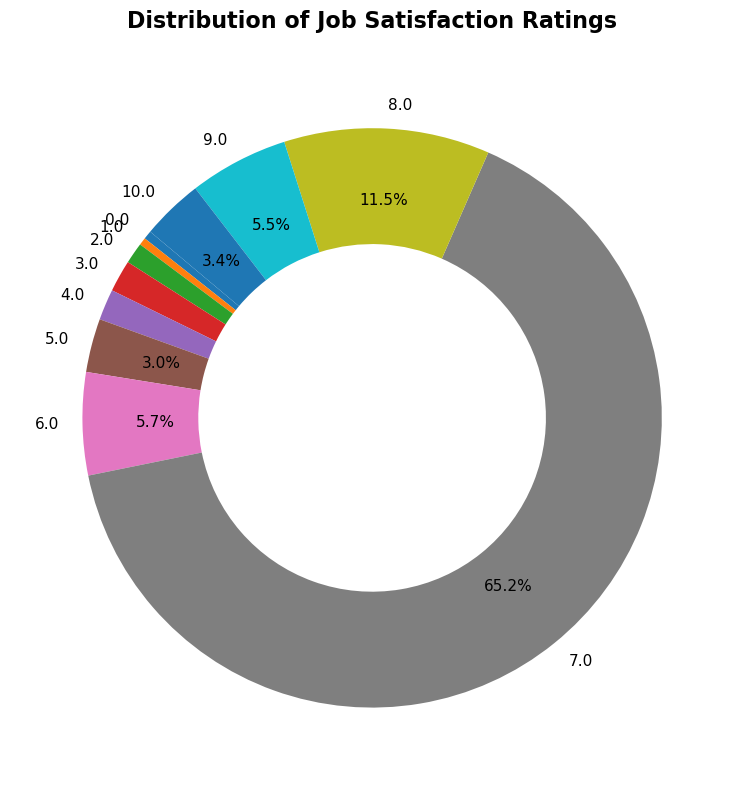

In [22]:
import matplotlib.pyplot as plt

# Count and sort values
jobsat_counts = jobsat_data.value_counts().sort_index()

# Function to hide very small percentages
def autopct_format(pct):
    return f'{pct:.1f}%' if pct > 2 else ''

# Create figure
plt.figure(figsize=(10, 8))

# Donut chart
wedges, texts, autotexts = plt.pie(
    jobsat_counts,
    labels=jobsat_counts.index,
    autopct=autopct_format,
    startangle=140,
    pctdistance=0.75,
    labeldistance=1.08,
    wedgeprops=dict(width=0.4),
    textprops=dict(fontsize=11)
)

# Title
plt.title(
    'Distribution of Job Satisfaction Ratings',
    fontsize=16,
    fontweight='bold',
    pad=20
)

plt.tight_layout()
plt.show()

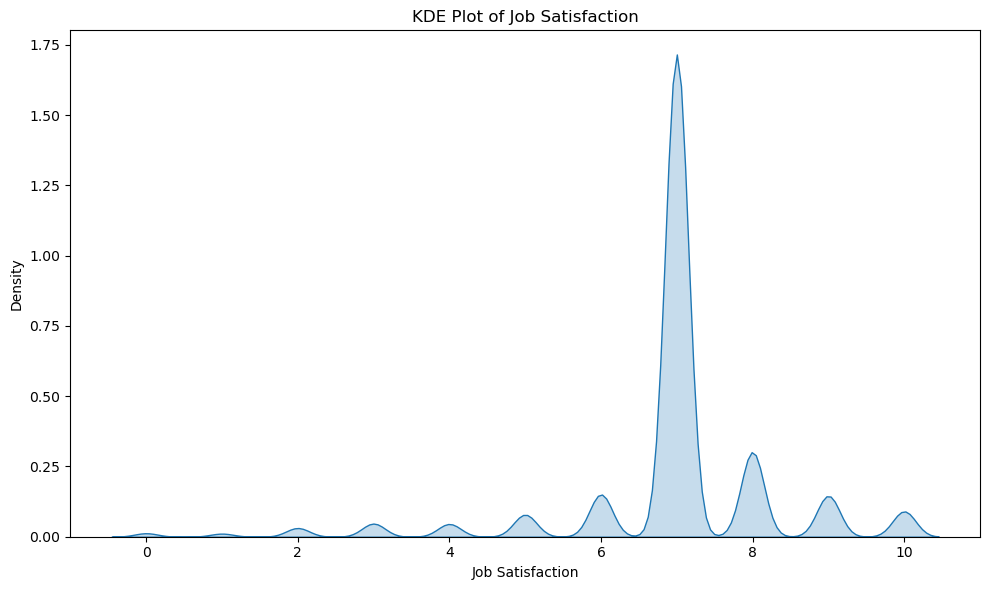

In [23]:
# Alternative: KDE plot for JobSat distribution

plt.figure(figsize=(10,6))

sns.kdeplot(
    pd.to_numeric(jobsat_data, errors='coerce'),
    fill=True
)

plt.title('KDE Plot of Job Satisfaction')
plt.xlabel('Job Satisfaction')
plt.ylabel('Density')

plt.tight_layout()
plt.show()

### Step 6: Programming Languages Analysis

- Compare the frequency of programming languages in `LanguageHaveWorkedWith` and `LanguageWantToWorkWith`.
  
- Visualize the overlap or differences using a Venn diagram or a grouped bar chart.

In [24]:
# Split languages worked with
worked = df['LanguageHaveWorkedWith'].dropna().str.split(';')

# Split languages wanted to work with
wanted = df['LanguageWantToWorkWith'].dropna().str.split(';')

In [25]:
# Count frequencies for worked languages
worked_counts = worked.explode().value_counts().head(10)

print(worked_counts)

LanguageHaveWorkedWith
JavaScript                 43184
HTML/CSS                   37508
Python                     30719
SQL                        30682
TypeScript                 28842
Bash/Shell (all shells)    20412
Java                       18239
C#                         16318
C++                        13827
C                          12184
Name: count, dtype: int64


In [26]:
# Count frequencies for wanted languages
wanted_counts = wanted.explode().value_counts().head(10)

print(wanted_counts)

LanguageWantToWorkWith
Python                     34732
JavaScript                 23774
SQL                        22400
HTML/CSS                   20721
TypeScript                 20239
Rust                       17232
Go                         13837
Bash/Shell (all shells)    13744
C#                         12921
C++                        10873
Name: count, dtype: int64


In [27]:
# Combine top languages into one dataframe

lang_compare = pd.DataFrame({
    'WorkedWith': worked_counts,
    'WantToWorkWith': wanted_counts
}).fillna(0)

print(lang_compare)

                         WorkedWith  WantToWorkWith
Bash/Shell (all shells)     20412.0         13744.0
C                           12184.0             0.0
C#                          16318.0         12921.0
C++                         13827.0         10873.0
Go                              0.0         13837.0
HTML/CSS                    37508.0         20721.0
Java                        18239.0             0.0
JavaScript                  43184.0         23774.0
Python                      30719.0         34732.0
Rust                            0.0         17232.0
SQL                         30682.0         22400.0
TypeScript                  28842.0         20239.0


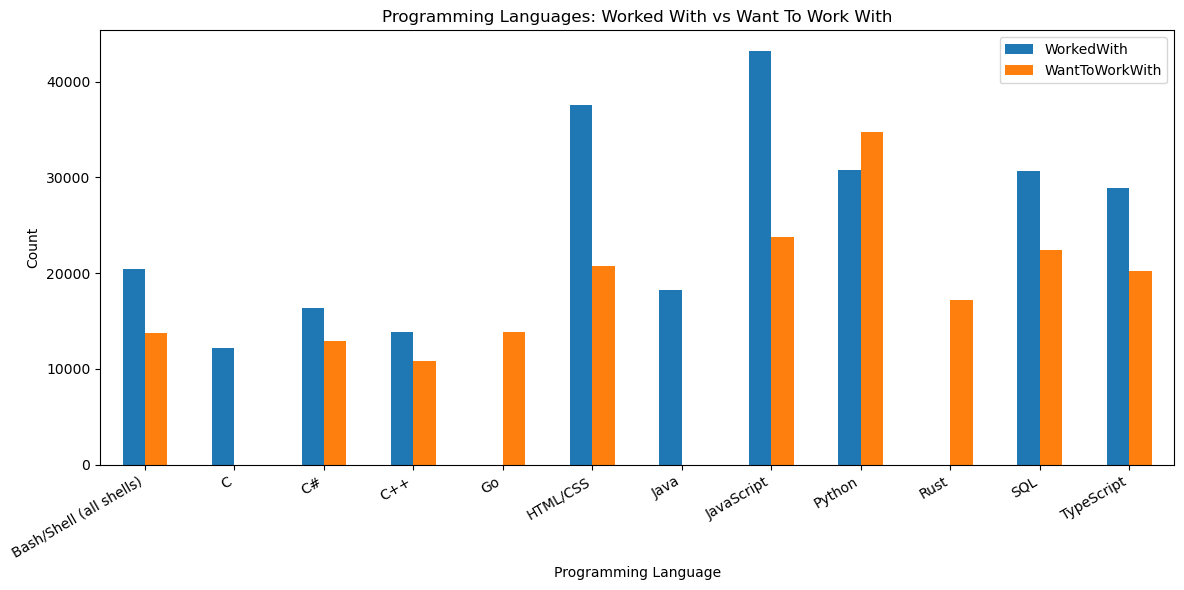

In [28]:
# Create grouped bar chart

lang_compare.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title('Programming Languages: Worked With vs Want To Work With')
plt.xlabel('Programming Language')
plt.ylabel('Count')

plt.xticks(rotation=30, ha='right')

plt.tight_layout()
plt.show()

### Step 7: Analyze Remote Work Trends

- Visualize the distribution of RemoteWork by region using a grouped bar chart or heatmap.

In [29]:
# Select top countries
top_countries = df['Country'].value_counts().nlargest(5).index

remote_df = df[df['Country'].isin(top_countries)]

In [30]:
# Create cross-tabulation for Country and RemoteWork

remote_region = pd.crosstab(
    remote_df['Country'],
    remote_df['RemoteWork']
)

print(remote_region)

RemoteWork                                          Hybrid (some remote, some in-person)  \
Country                                                                                    
Germany                                                                             3098   
India                                                                               2290   
Ukraine                                                                              828   
United Kingdom of Great Britain and Northern Ir...                                  1765   
United States of America                                                            8204   

RemoteWork                                          In-person  Remote  
Country                                                                
Germany                                                   647    1202  
India                                                    1088     853  
Ukraine                                                   111    17

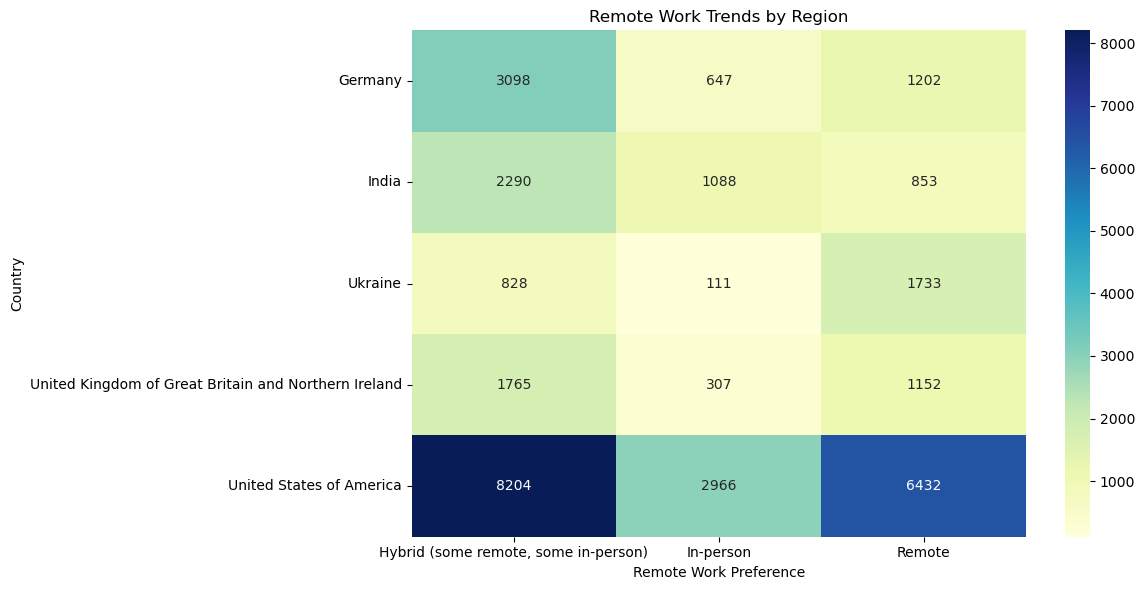

In [31]:
# Visualize remote work trends by region

plt.figure(figsize=(12,6))

sns.heatmap(
    remote_region,
    annot=True,
    fmt='d',
    cmap='YlGnBu'
)

plt.title('Remote Work Trends by Region')
plt.xlabel('Remote Work Preference')
plt.ylabel('Country')

plt.tight_layout()
plt.show()

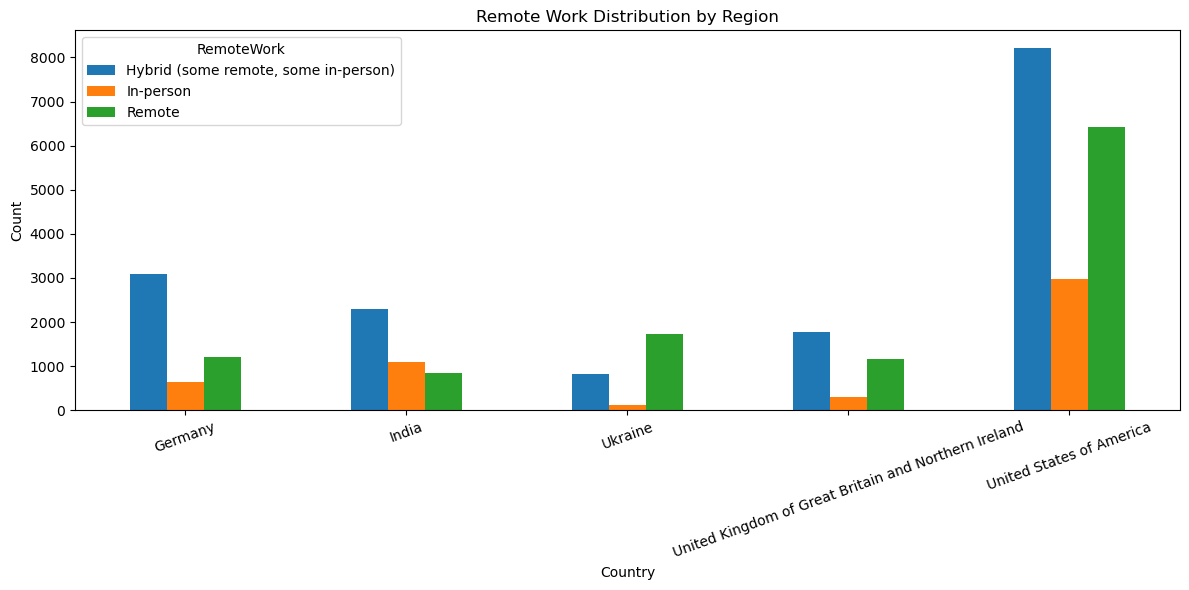

In [32]:
# Alternative grouped bar chart

remote_region.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title('Remote Work Distribution by Region')
plt.xlabel('Country')
plt.ylabel('Count')

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

### Step 8: Correlation between Job Satisfaction and Experience

- Analyze the correlation between overall job satisfaction (`JobSat`) and `YearsCodePro`.
  
- Calculate the Pearson or Spearman correlation coefficient.

In [33]:
# Convert columns to numeric
df['YearsCodePro'] = pd.to_numeric(
    df['YearsCodePro'],
    errors='coerce'
)

df['JobSat'] = pd.to_numeric(
    df['JobSat'],
    errors='coerce'
)

In [34]:
# Remove missing values
corr_df = df[['YearsCodePro', 'JobSat']].dropna()

In [35]:
# Calculate Pearson correlation
pearson_corr = corr_df['YearsCodePro'].corr(
    corr_df['JobSat'],
    method='pearson'
)

print("Pearson Correlation:", pearson_corr)

Pearson Correlation: 0.06649076820056875


In [36]:
# Calculate Spearman correlation
spearman_corr = corr_df['YearsCodePro'].corr(
    corr_df['JobSat'],
    method='spearman'
)

print("Spearman Correlation:", spearman_corr)

Spearman Correlation: 0.10647562176737671


### Step 9: Cross-tabulation Analysis (Employment vs. Education Level)

- Analyze the relationship between employment status (`Employment`) and education level (`EdLevel`).

- **Instruction**: Create a cross-tabulation using `pd.crosstab()` and visualize it with a stacked bar plot if possible.

In [37]:
# Create cross-tabulation between Employment and EdLevel

employment_education = pd.crosstab(
    df['Employment'],
    df['EdLevel']
)

print(employment_education)

EdLevel                                             Associate degree (A.A., A.S., etc.)  \
Employment                                                                                
Employed, full-time                                                                1059   
Employed, full-time;Employed, part-time                                               9   
Employed, full-time;Independent contractor, fre...                                  104   
Employed, full-time;Independent contractor, fre...                                   11   
Employed, full-time;Independent contractor, fre...                                    0   
...                                                                                 ...   
Student, full-time;Student, part-time;Employed,...                                    0   
Student, full-time;Student, part-time;Retired                                         0   
Student, part-time                                                                   12   

In [39]:
# Select top employment categories for cleaner visualization
top_emp = df['Employment'].value_counts().nlargest(8).index

filtered_df = df[df['Employment'].isin(top_emp)].copy()

In [40]:
# Shorten education level names

filtered_df['EdLevel_Short'] = filtered_df['EdLevel'].replace({
    "Bachelor’s degree (B.A., B.S., B.Eng., etc.)": "Bachelor's",
    "Master’s degree (M.A., M.S., M.Eng., MBA, etc.)": "Master's",
    "Professional degree (JD, MD, Ph.D, Ed.D, etc.)": "Professional",
    "Associate degree (A.A., A.S., etc.)": "Associate",
    "Some college/university study without earning a degree": "Some College",
    "Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)": "Secondary School",
    "Primary/elementary school": "Primary School",
    "Something else": "Other"
})

In [41]:
# Create cross-tabulation

employment_education = pd.crosstab(
    filtered_df['Employment'],
    filtered_df['EdLevel_Short']
)

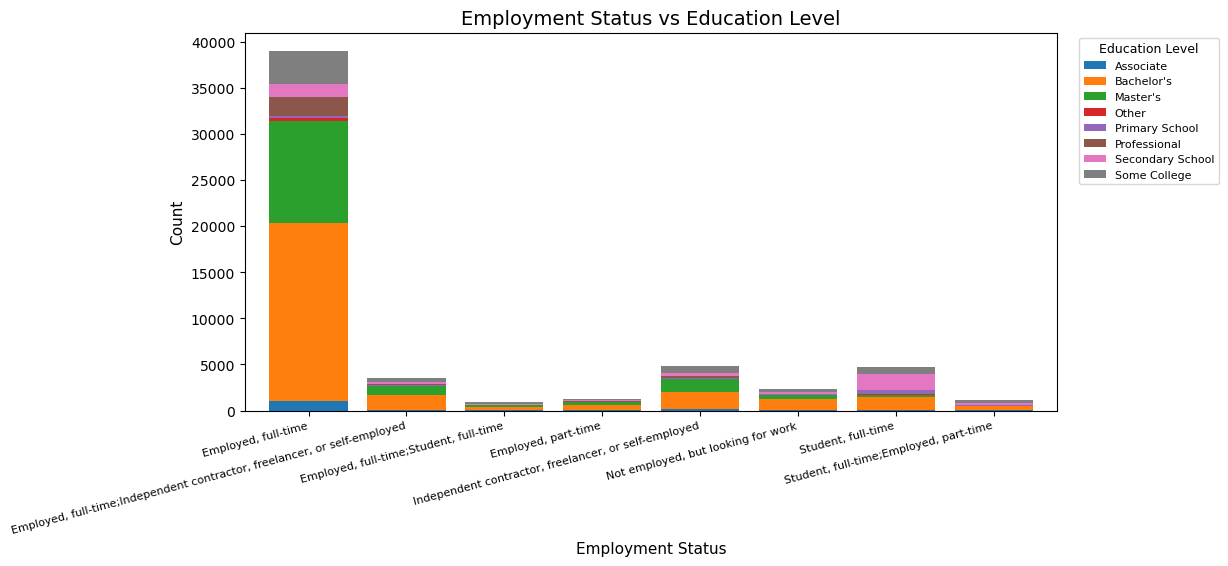

In [42]:
# Improved stacked bar visualization

ax = employment_education.plot(
    kind='bar',
    stacked=True,
    figsize=(13,6),
    width=0.8
)

plt.title('Employment Status vs Education Level', fontsize=14)
plt.xlabel('Employment Status', fontsize=11)
plt.ylabel('Count', fontsize=11)

# Improve x-axis labels
plt.xticks(rotation=15, ha='right', fontsize=8)

# Place legend outside neatly
plt.legend(
    title='Education Level',
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    fontsize=8,
    title_fontsize=9
)

# Add margins manually instead of tight_layout
plt.subplots_adjust(right=0.75, bottom=0.25)

plt.show()

### Step 10: Export Cleaned Data

- Save the cleaned dataset to a new CSV file for further use or sharing.

In [43]:
# Save cleaned dataset to a new CSV file

df.to_csv('cleaned_survey_data.csv', index=False)

print("Cleaned dataset exported successfully.")

Cleaned dataset exported successfully.


### Summary:

In this lab, you practiced key skills in exploratory data analysis, including:

- Examining the structure and content of the Stack Overflow survey dataset to understand its variables and data types.

- Identifying and addressing missing data to ensure the dataset's quality and completeness.

- Summarizing and visualizing key variables such as job satisfaction, programming languages, and remote work trends.

- Analyzing relationships in the data using techniques like:
    - Comparing programming languages respondents have worked with versus those they want to work with.
      
    - Exploring remote work preferences by region.

- Investigating correlations between professional coding experience and job satisfaction.

- Performing cross-tabulations to analyze relationships between employment status and education levels.